# NIK debug: simulated vs real data (one slice)
Compares the sim radial dataset (XCAT) and the real twix slice 13 (grasp-pro precompute).
Key suspected difference: **sampling regime** (spokes/frame, #frames, continuous vs discrete time).
Cells: load both -> regime table -> trajectories -> coord histograms -> spoke before/after envelope
-> train/val split -> manual-param training (sim & real) -> predicted vs measured k-space on a spoke.

In [1]:
%matplotlib inline
import sys, numpy as np, torch
import matplotlib.pyplot as plt
sys.path.insert(0, '/scratch/rnga/vvpshenov/grasp_pro_py')
from nik_io import load_event
from nik_train import prepare_tensors
from nik_recon import ifft1d_kz_to_z, make_multicoil_time_radial_dataset
from nik_model import WIRE_KXY_COIL_T_REIM
from kspace_normalization import compute_dcf_radial, compute_radius, KSpaceNormalizer
from nik_focal_loss import composable_kspace_loss
import nik_adapter as A
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# continuous-time sim (9 spokes/slice/frame, 181 frames) - matches the real sparse regime
SIM = '/scratch/rnga/vvpshenov/XCAT-ERIC/results/simulation_results_20260527T175428.mat'
REAL = '/scratch/rnga/vvpshenov/grasp_pro_py/results_ref'

def tonp(t): return t.detach().cpu().numpy()

In [2]:
# --- load SIM (one z-slice) ---
ev = load_event(SIM, load_images=False, load_coil_maps=False)
k = np.transpose(ev['k'], (0,2,1,3)); tr = np.transpose(ev['traj'], (0,2,1,3))
st = ev.get('spoke_timing_dce')                       # continuous per-spoke time (ms)
if st is not None:
    st = np.asarray(st)
    if st.shape[0]==k.shape[0] and st.shape[1]!=k.shape[0]: st = st.T   # (T,S)->(S,T)
st_max = float(st.max()) if st is not None else None
kt, trt, scales, dims, ks = prepare_tensors(k, tr, str(dev))
kimg, nz, nro, _ = ifft1d_kz_to_z(kt, trt, 0)
xs, ts, cs, yrs, sps, ros, frs, metas = make_multicoil_time_radial_dataset(
    kimg, trt, scales, dims, z_slice_idx=nz//2, n_slices=nz, compute_device=str(dev),
    spoke_timing_dce=st, t_max_ms=st_max)
dcf_s = compute_dcf_radial(xs); norm_s = KSpaceNormalizer(); norm_s.fit(xs, yrs, dcf=dcf_s)
ys = norm_s.normalize(xs, yrs)
SIMD = dict(x=xs,t=ts,c=cs,yr=yrs,y=ys,sp=sps,fr=frs,dcf=dcf_s,norm=norm_s,
            n_spoke=int(sps.unique().numel()), n_frame=int(frs.unique().numel()), RO=dims[3])

# --- load REAL (slice 13) ---
d = A.make_radial_dataset(REAL, 13, compute_device=str(dev))
xr_,tr_,cr_,yrr = d['x_all'],d['t_all'],d['coil_all'],d['y_all_raw']
dcf_r = compute_dcf_radial(xr_); norm_r = KSpaceNormalizer(); norm_r.fit(xr_, yrr, dcf=dcf_r)
yr2 = norm_r.normalize(xr_, yrr)
REALD = dict(x=xr_,t=tr_,c=cr_,yr=yrr,y=yr2,sp=d['spoke_id_all'],fr=d['frame_id_all'],
             dcf=dcf_r,norm=norm_r,n_spoke=int(d['spoke_id_all'].unique().numel()),
             n_frame=int(d['frame_id_all'].unique().numel()), RO=d['meta']['nx'])

for D in (SIMD, REALD):
    m0 = (D['fr']==D['fr'].min()) & (D['c']==0)
    D['spk_per_frame'] = int(D['sp'][m0].unique().numel())

print(f"{'':6} {'samples':>10} {'spokes':>8} {'frames':>7} {'spk/frame':>10} {'RO':>5} {'t-vals':>7}")
for tag,D in [('SIM',SIMD),('REAL',REALD)]:
    print(f"{tag:6} {D['x'].shape[0]:10d} {D['n_spoke']:8d} {D['n_frame']:7d} "
          f"{D['spk_per_frame']:10d} {D['RO']:5d} {int(D['t'].unique().numel()):7d}")

          samples   spokes  frames  spk/frame    RO  t-vals
SIM       2867040        9     181          9   220    1629
REAL      5253120     1710     342          5   384    1710


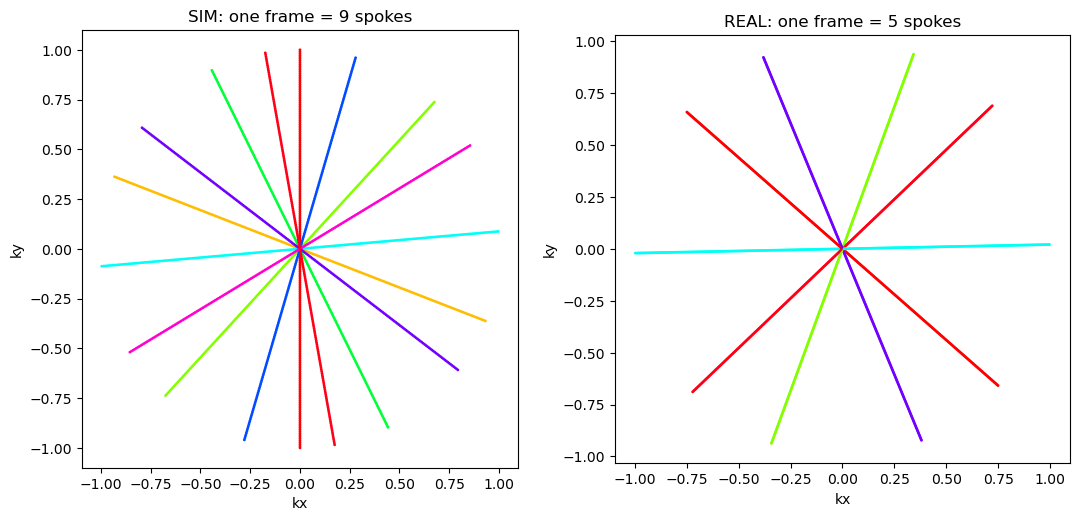

In [3]:
# --- k-space trajectories: one frame's spokes (kx vs ky) ---
fig, ax = plt.subplots(1, 2, figsize=(11,5.2))
for a,(tag,D) in zip(ax,[('SIM',SIMD),('REAL',REALD)]):
    m = (D['fr']==D['fr'].min()) & (D['c']==0)              # one frame, coil 0
    kx,ky = tonp(D['x'][m,0]), tonp(D['x'][m,1])
    a.scatter(kx,ky,s=1,c=tonp(D['sp'][m]),cmap='hsv'); a.set_aspect('equal')
    nspk = int(D['sp'][m].unique().numel())
    a.set_title(f'{tag}: one frame = {nspk} spokes'); a.set_xlabel('kx'); a.set_ylabel('ky')
plt.tight_layout(); plt.show()

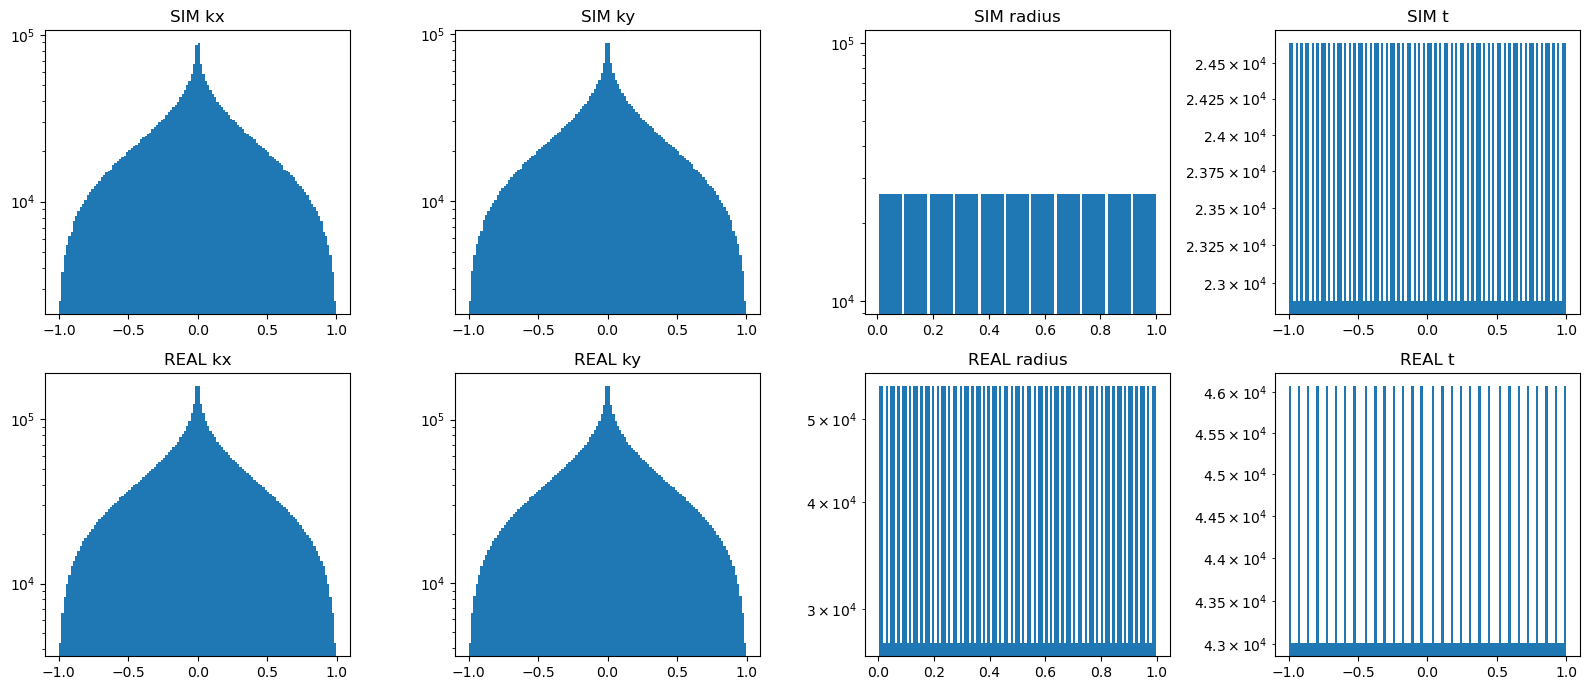

In [4]:
# --- histograms of k-coordinates: kx, ky, radius, t ---
fig, ax = plt.subplots(2, 4, figsize=(16,7))
for row,(tag,D) in zip(ax,[('SIM',SIMD),('REAL',REALD)]):
    r = tonp(compute_radius(D['x']))
    for a,(lab,v) in zip(row,[('kx',tonp(D['x'][:,0])),('ky',tonp(D['x'][:,1])),('radius',r),('t',tonp(D['t']))]):
        a.hist(v,bins=120,color='C0'); a.set_title(f'{tag} {lab}'); a.set_yscale('log')
plt.tight_layout(); plt.show()

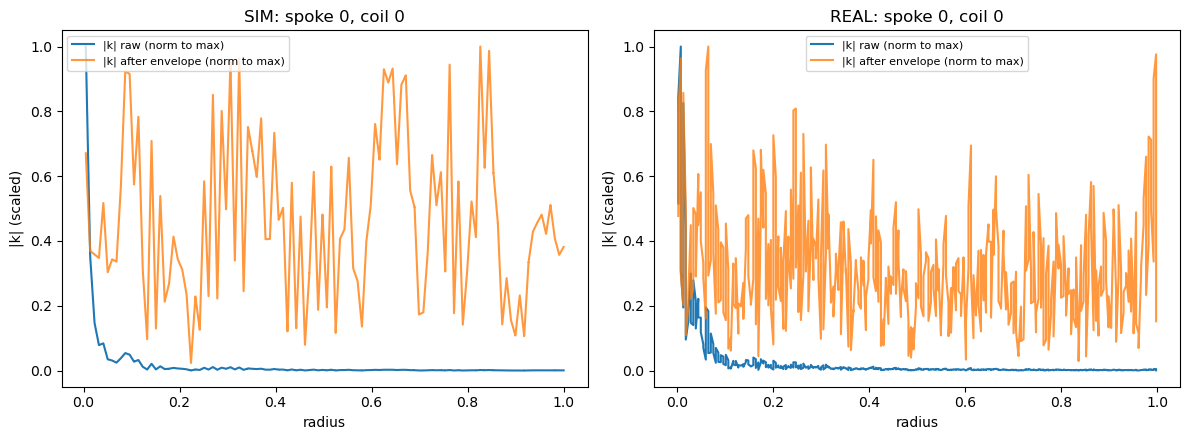

In [5]:
# --- one spoke signal before / after envelope normalization (coil 0) ---
fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
for a,(tag,D) in zip(ax,[('SIM',SIMD),('REAL',REALD)]):
    sp0 = int(D['sp'].min())
    m = (D['sp']==sp0) & (D['c']==0) & (D['fr']==D['fr'].min())
    r = tonp(compute_radius(D['x'][m]))
    raw = tonp((D['yr'][m,0]**2+D['yr'][m,1]**2).sqrt())
    nrm = tonp((D['y'][m,0]**2+D['y'][m,1]**2).sqrt())
    o = np.argsort(r)
    a.plot(r[o], raw[o]/ (raw.max()+1e-12), label='|k| raw (norm to max)')
    a.plot(r[o], nrm[o]/ (nrm.max()+1e-12), label='|k| after envelope (norm to max)', alpha=.8)
    a.set_title(f'{tag}: spoke {sp0}, coil 0'); a.set_xlabel('radius'); a.set_ylabel('|k| (scaled)'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [6]:
# --- train / val split across spokes (hold out a fraction of UNIQUE spokes) ---
def split(D, frac=0.9, seed=0):
    uniq = D['sp'].unique()
    g = torch.Generator(device=D['sp'].device).manual_seed(seed)
    perm = uniq[torch.randperm(uniq.numel(), generator=g, device=D['sp'].device)]
    ntr = max(1,int(uniq.numel()*frac))
    trm = torch.isin(D['sp'], perm[:ntr])
    return torch.where(trm)[0], torch.where(~trm)[0], ntr, uniq.numel()-ntr
for tag,D in [('SIM',SIMD),('REAL',REALD)]:
    tri,hei,ntr,nhe = split(D)
    D['train_idx'],D['heldout_idx']=tri,hei
    print(f'{tag}: {ntr} train spokes / {nhe} heldout spokes  ->  '
          f'{tri.numel()} train pts / {hei.numel()} heldout pts')

SIM: 8 train spokes / 1 heldout spokes  ->  2548480 train pts / 318560 heldout pts
REAL: 1539 train spokes / 171 heldout spokes  ->  4727808 train pts / 525312 heldout pts


## Manual training - SIM (edit PARAMS, run)

In [7]:
def train_one(D, PARAMS, steps=3000):
    p=PARAMS; torch.manual_seed(0)
    m=WIRE_KXY_COIL_T_REIM(n_coils=8,coil_embed_dim=p.get('coil_embed_dim',8),
        hidden=p['hidden'],depth=p['depth'],w0=p['w0'],s0=p['s0']).to(dev)
    opt=torch.optim.Adam(m.parameters(),lr=p['lr'],weight_decay=p.get('wd',0.0))
    xi,ti,ci,yi,wi=(D['x'][D['train_idx']],D['t'][D['train_idx']],D['c'][D['train_idx']],
                    D['y'][D['train_idx']],D['dcf'][D['train_idx']]); n=xi.shape[0]
    xh,th,ch,yh=(D['x'][D['heldout_idx']],D['t'][D['heldout_idx']],D['c'][D['heldout_idx']],D['y'][D['heldout_idx']])
    for s in range(steps+1):
        i=torch.randint(0,n,(p['batch'],),device=dev); opt.zero_grad(set_to_none=True)
        loss=composable_kspace_loss(m(xi[i],ti[i],ci[i]),yi[i],dcf=wi[i],use_dcf=True,
                                    dcf_power=p['dcf_power'],return_diagnostics=False)
        loss.backward(); torch.nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
        if s%(steps//6)==0:
            with torch.no_grad():
                hl=torch.nn.functional.mse_loss(m(xh,th,ch),yh).item() if xh.numel() else float('nan')
            print(f'  step {s:5d}  train {float(loss):.4f}  heldout_mse {hl:.4f}',flush=True)
    return m

PARAMS_SIM = dict(hidden=64, depth=6, w0=32, s0=18, lr=1e-4, batch=4096, dcf_power=0.0, wd=3e-3)
print('SIM training:'); model_sim = train_one(SIMD, PARAMS_SIM, steps=3000)

SIM training:


  step     0  train 1.1267  heldout_mse 1.0095


/home/rnga/vvpshenov/tmp/ipykernel_2406733/44662487.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f'  step {s:5d}  train {float(loss):.4f}  heldout_mse {hl:.4f}',flush=True)


  step   500  train 1.1083  heldout_mse 0.5300


  step  1000  train 1.1472  heldout_mse 0.5294


  step  1500  train 1.0771  heldout_mse 0.5121


  step  2000  train 1.0482  heldout_mse 0.4971


  step  2500  train 1.0294  heldout_mse 0.4917


  step  3000  train 1.0356  heldout_mse 0.4847


## Manual training - REAL (edit PARAMS, run)

In [8]:
PARAMS_REAL = dict(hidden=64, depth=6, w0=32, s0=18, lr=1e-4, batch=4096, dcf_power=0.5, wd=3e-3)
print('REAL training:'); model_real = train_one(REALD, PARAMS_REAL, steps=3000)

REAL training:
  step     0  train 1.0166  heldout_mse 0.7117


  step   500  train 1.0213  heldout_mse 0.4688


  step  1000  train 1.0491  heldout_mse 0.4696


  step  1500  train 1.0037  heldout_mse 0.4686


  step  2000  train 1.0630  heldout_mse 0.4685


  step  2500  train 0.9871  heldout_mse 0.4689


  step  3000  train 0.9894  heldout_mse 0.4684


In [ ]:
# ============================================================================
# Latest AutoScientist champion  (nik-autoresearch run nik_2901994, exp c8_herm_sym)
#   ref_neutral AUC 0.5518  (baseline seed 0.2512)  |  ref_grasp AUC 0.6564
# Full champion CODE lives in:
#   /scratch/rnga/vvpshenov/nik-autoresearch/experiments/runs/nik_2901994/champion/
# ----------------------------------------------------------------------------
# NOTE: train_one() above + the ORIGINAL WIRE/loss only consume the BACKBONE subset
# (hidden/depth/w0/s0/lr/batch/dcf_power/wd). The evolved mechanisms below
# (Fourier-feature encoding, weight-EMA, temporal-TV, Hermitian symmetry, soft
# envelope_exponent) are CODE in the champion pipeline, NOT in this notebook -- to
# reproduce the FULL champion here you must port champion/nik_model.py + nik_entry.py
# + nik_focal_loss.py + kspace_normalization.py. Feeding this dict to the current
# train_one() runs the backbone only (the extra keys are ignored).
# ============================================================================
CHAMPION_HP = dict(
    # --- WIRE backbone (consumed by train_one as-is) ---
    hidden=128, depth=8, w0=62.0, s0=15.0, coil_embed_dim=8,
    lr=1e-5, wd=3e-3, batch=16384, grad_clip=1.0,
    steps=3000, warmup_steps=300, subsample_frac=0.9,
    scheduler_factor=0.5, scheduler_patience=30, scheduler_min_lr=1e-7,
    # --- normalization / DCF (softer envelope spares the noisy high-|k|) ---
    dcf_method='simple_ramp', dcf_power=0.5, use_dcf=True, envelope_exponent=0.3,
    # --- Fourier-feature coordinate encoding  (c1_ff_kxy_encode -> c5_ksigma -> c6_ff_taper) ---
    k_freq=64, k_sigma=2.0, ff_seed=0, ff_taper_sigma=4.0,
    # --- weight EMA  (c3_ema_weights) ---
    use_ema=True, ema_decay=0.999,
    # --- temporal-TV prior  (c7_temporal_tv) ---
    tv_lambda=0.03, tv_dt=0.05,
    # --- soft Hermitian conjugate-symmetry prior  (c8_herm_sym) ---
    herm_lambda=0.02,
)
print(f'champion c8_herm_sym: {len(CHAMPION_HP)} params loaded into CHAMPION_HP')
print('backbone subset works with train_one(); FF/EMA/TV/Herm need the champion pipeline code.')
# backbone-only quick run (FF/EMA/TV/Hermitian NOT applied -- extra keys ignored):
# model_champ = train_one(REALD, CHAMPION_HP, steps=3000)

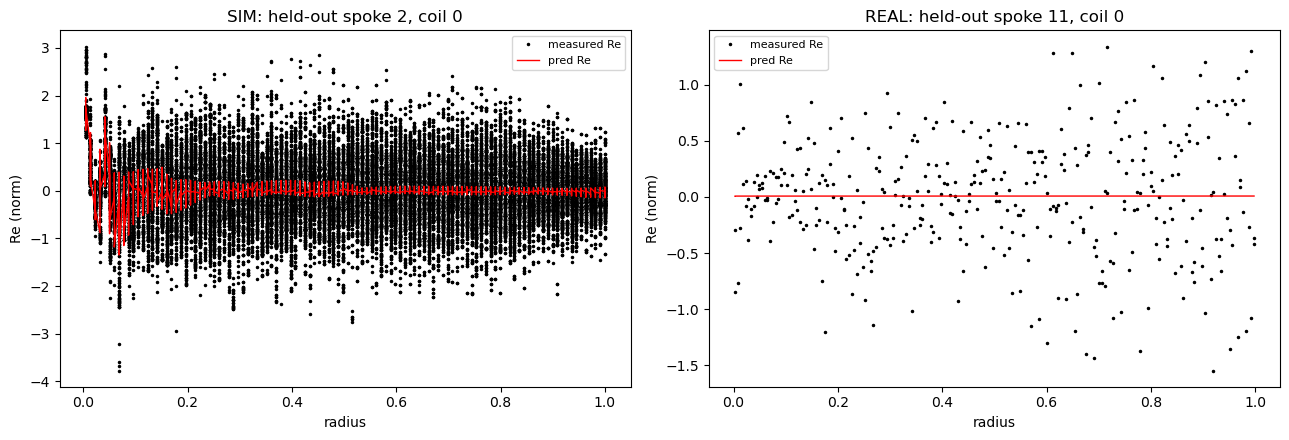

In [9]:
# --- predicted vs measured k-space along ONE held-out spoke (coil 0) ---
def pred_vs_meas(ax, D, model, tag):
    sp0 = int(D['sp'][D['heldout_idx']][0])             # a held-out spoke
    m = (D['sp']==sp0) & (D['c']==0)
    r = tonp(compute_radius(D['x'][m])); o = np.argsort(r)
    with torch.no_grad():
        pr = tonp(model(D['x'][m], D['t'][m], D['c'][m]))
    meas = tonp(D['y'][m])
    ax.plot(r[o], meas[o,0], 'k.', ms=3, label='measured Re')
    ax.plot(r[o], pr[o,0], 'r-', lw=1, label='pred Re')
    ax.set_title(f'{tag}: held-out spoke {sp0}, coil 0'); ax.set_xlabel('radius'); ax.set_ylabel('Re (norm)'); ax.legend(fontsize=8)
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
pred_vs_meas(ax[0], SIMD, model_sim, 'SIM')
pred_vs_meas(ax[1], REALD, model_real, 'REAL')
plt.tight_layout(); plt.show()